In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Initial review

In [3]:
#read file
df = pd.read_csv("../data/real_estate_dataset.csv")

In [4]:
df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [5]:
print("Row: " , len(df))
print("Columns: " , len(df.columns))
print("Nan values: " , df.isna().sum().sum())
print("duplicate values: " , df.duplicated().sum())

Row:  500
Columns:  12
Nan values:  0
duplicate values:  0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         500 non-null    float64
 2   Num_Bedrooms        500 non-null    int64  
 3   Num_Bathrooms       500 non-null    int64  
 4   Num_Floors          500 non-null    int64  
 5   Year_Built          500 non-null    int64  
 6   Has_Garden          500 non-null    int64  
 7   Has_Pool            500 non-null    int64  
 8   Garage_Size         500 non-null    int64  
 9   Location_Score      500 non-null    float64
 10  Distance_to_Center  500 non-null    float64
 11  Price               500 non-null    float64
dtypes: float64(4), int64(8)
memory usage: 47.0 KB


In [7]:
df.describe()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,144.481833,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,125.750000,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,250.500000,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,375.250000,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


## Data cleanup

In [8]:
df["Square_Feet"] = np.round(df["Square_Feet"] , 2)

In [9]:
df["Location_Score"] = np.round(df["Location_Score"] , 2)

In [10]:
df["Distance_to_Center"] = np.round(df["Distance_to_Center"],2)

In [11]:
df["Price"] = np.round(df["Price"],2)

In [12]:
df.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.64,1,3,3,1967,1,1,48,8.30,5.94,602134.82
1,2,287.68,1,2,1,1949,0,1,37,6.06,10.83,591425.14
2,3,233.00,1,3,2,1923,1,0,14,2.91,6.90,464478.70
3,4,199.66,5,2,2,1918,0,0,17,2.07,8.28,583105.66
4,5,89.00,4,3,3,1999,1,0,34,1.52,14.65,619879.14


## Data Analysis 

In [13]:
df["Year_Built"].value_counts().sort_values(ascending = False)

Year_Built
1959    12
1920    12
1901    10
1935     9
1907     9
        ..
1955     1
1952     1
1958     1
2006     1
1993     1
Name: count, Length: 121, dtype: int64

In [14]:
df["Has_Garden"].value_counts().sort_values(ascending = False)

Has_Garden
1    268
0    232
Name: count, dtype: int64

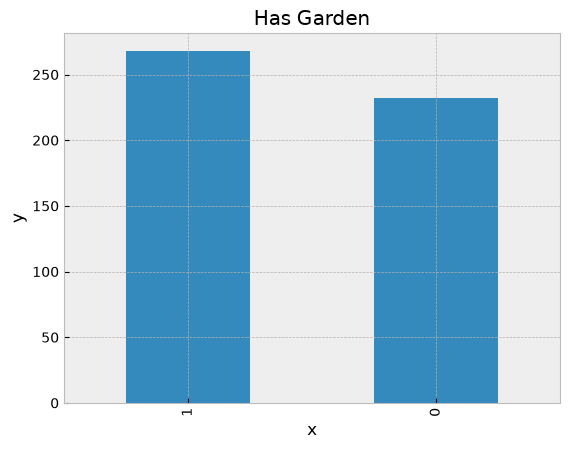

In [15]:
plt.style.use('bmh')
df["Has_Garden"].value_counts().sort_values(ascending = False).plot(kind = "bar")
plt.title("Has Garden")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [16]:
df["Has_Pool"].value_counts().sort_values(ascending = False)

Has_Pool
0    254
1    246
Name: count, dtype: int64

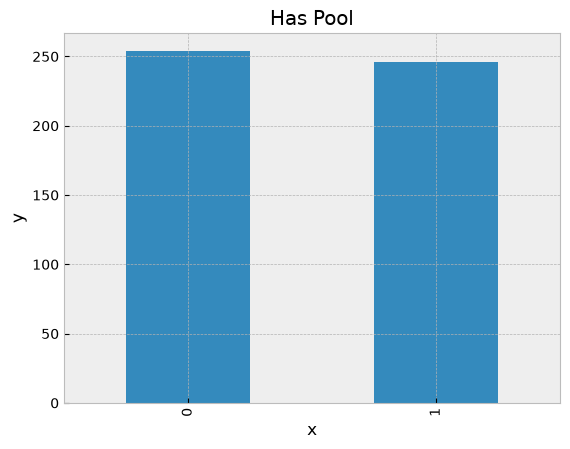

In [17]:
plt.style.use('bmh')
df["Has_Pool"].value_counts().sort_values(ascending = False).plot(kind = "bar")
plt.title("Has Pool")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [18]:
#Are pool houses close to the city center?
has_pool = df.groupby("Has_Pool")["Distance_to_Center"].mean().sort_values(ascending = False)

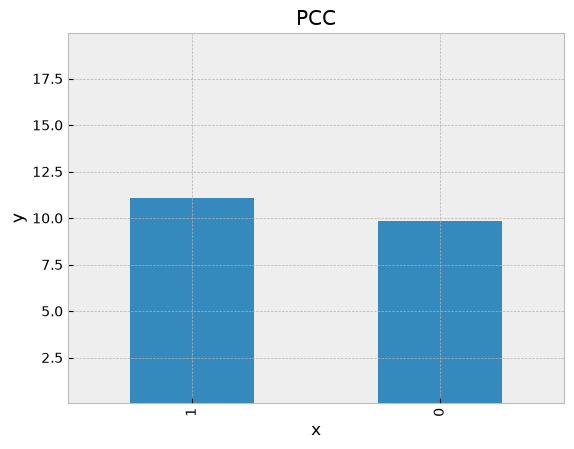

In [19]:
plt.style.use('bmh')
has_pool.plot(kind = "bar")
plt.title("PCC")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(df["Distance_to_Center"].min() , df["Distance_to_Center"].max())
plt.show()

In [20]:
#Do wet type homes have higher ratings?
year_location_score = df.groupby("Year_Built")["Location_Score"].mean().sort_index(ascending = False)

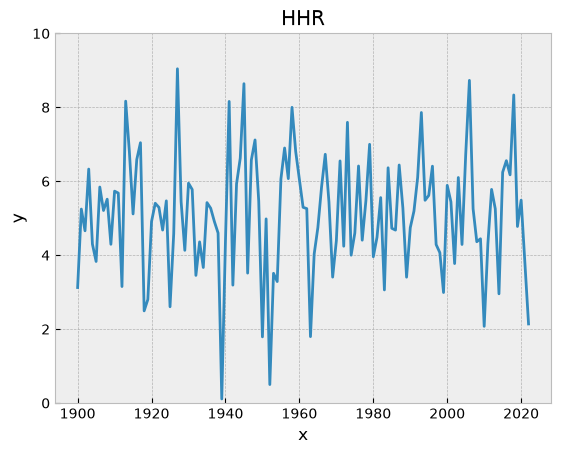

In [21]:
plt.style.use('bmh')
year_location_score.plot()
plt.title("HHR")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(df["Location_Score"].min() , df["Location_Score"].max())
plt.show()

In [22]:
df.to_csv("real_estate_dataset2.csv" , index = None)